In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print("✅ Librerías importadas")

✅ Librerías importadas


## 1️⃣ Cargar Resultados de Modelos

In [2]:
# Cargar resultados
results_df = pd.read_csv('model_comparison_results.csv')
print("📊 Resultados de modelos cargados:")
print(results_df)

📊 Resultados de modelos cargados:
                  Model  Train_Accuracy  Test_Accuracy  Train_Precision  \
0         Random Forest          0.8941         0.8700           0.9187   
1  XGBoost (GridSearch)          0.8782         0.8700           0.8136   
2              LightGBM          0.9145         0.8680           0.9078   
3              CatBoost          0.9781         0.8540           0.9912   
4     Stacking Ensemble          0.9032         0.8695           0.8993   
5      XGBoost (Optuna)          0.8872         0.8680           0.8737   

   Test_Precision  Train_Recall  Test_Recall  Train_F1  Test_F1  Train_AUC  \
0          0.8267        0.5270       0.4570    0.6698   0.5886     0.9443   
1          0.7882        0.5221       0.4939    0.6360   0.6073     0.9007   
2          0.7849        0.6460       0.4840    0.7548   0.5988     0.9650   
3          0.7122        0.9006       0.4742    0.9437   0.5693     0.9978   
4          0.7944        0.5914       0.4840    0.

## 2️⃣ Comparación de Accuracy entre Modelos

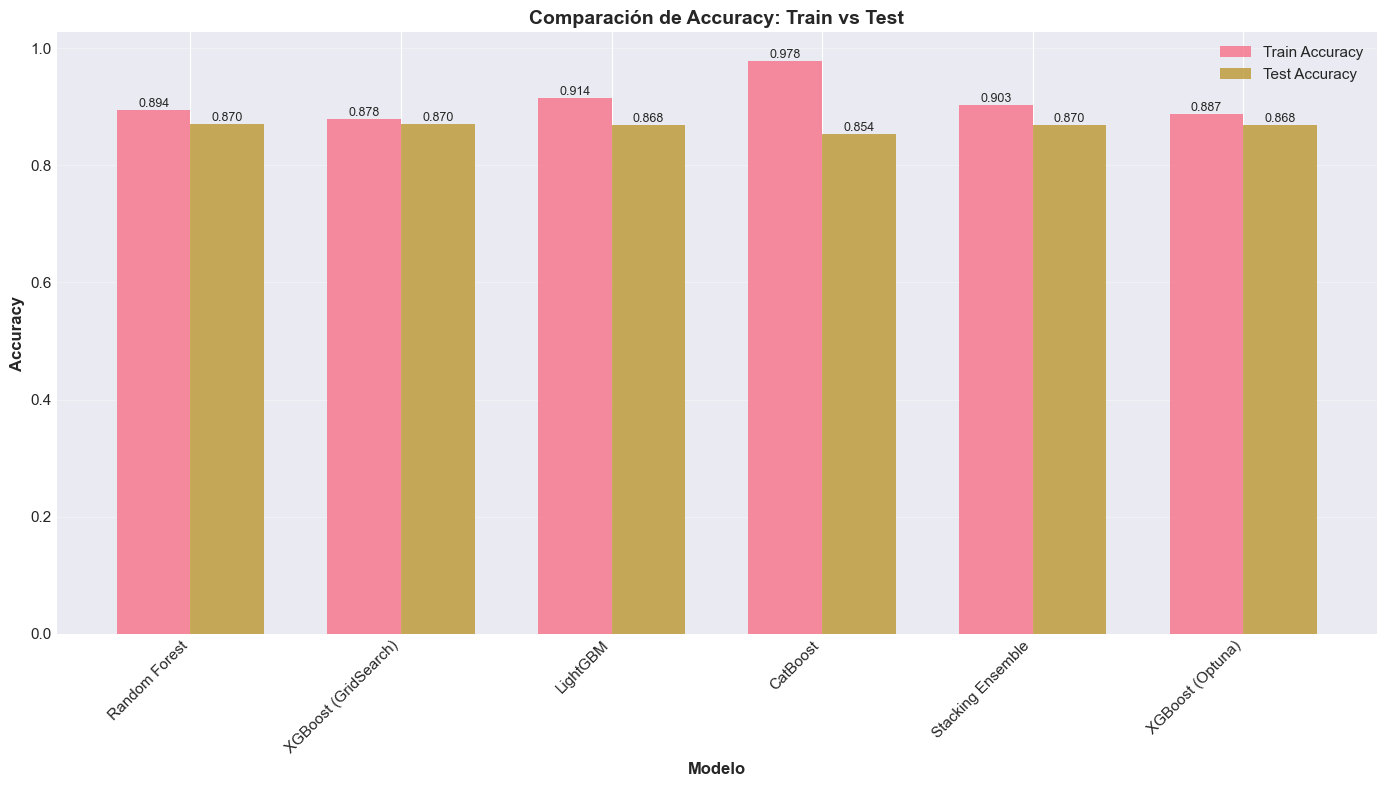

In [3]:
# Gráfico de barras comparativo - Accuracy
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(results_df))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['Train_Accuracy'], width, label='Train Accuracy', alpha=0.8)
bars2 = ax.bar(x + width/2, results_df['Test_Accuracy'], width, label='Test Accuracy', alpha=0.8)

ax.set_xlabel('Modelo', fontsize=12, weight='bold')
ax.set_ylabel('Accuracy', fontsize=12, weight='bold')
ax.set_title('Comparación de Accuracy: Train vs Test', fontsize=14, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Añadir valores en las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 3️⃣ Comparación de ROC-AUC (Métrica Principal)

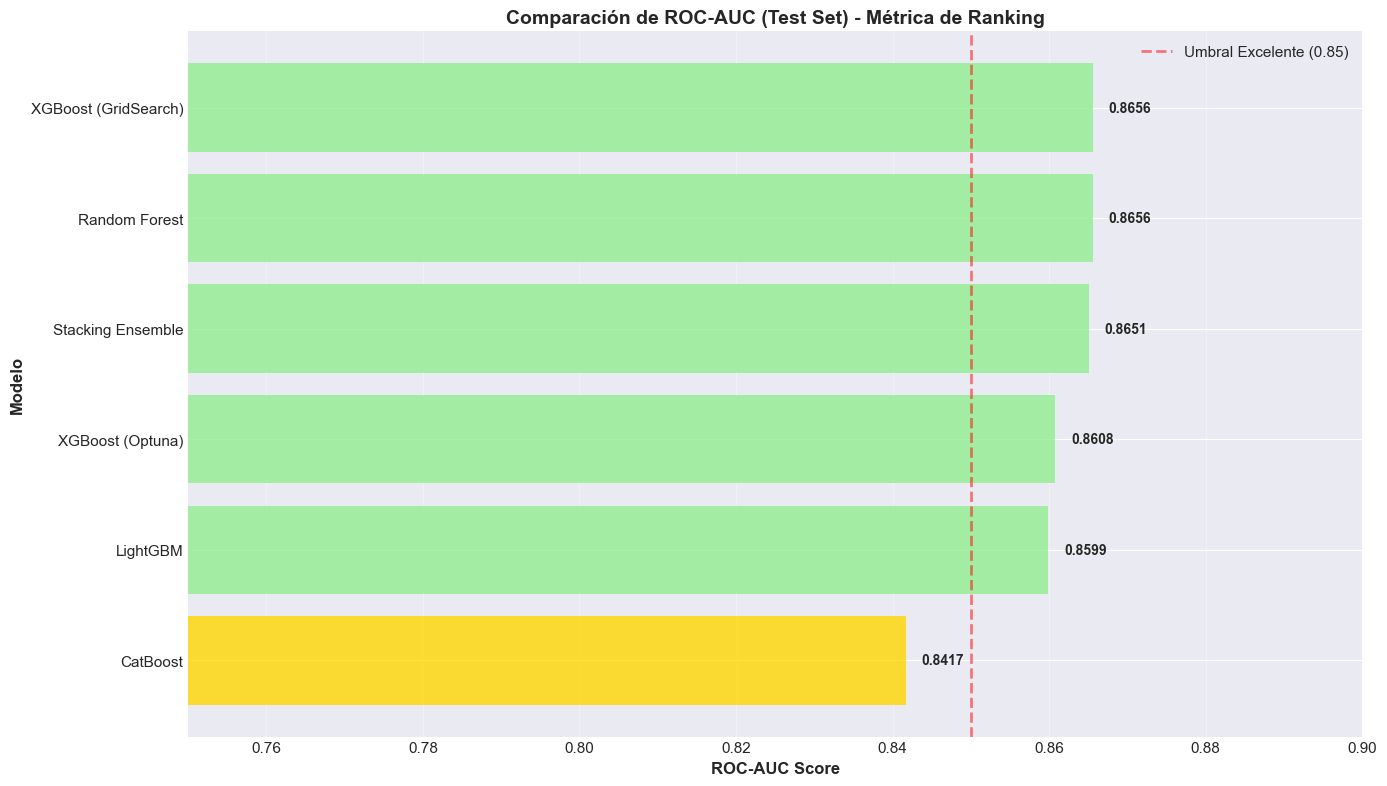


🏆 Modelo campeón: XGBoost (GridSearch) con ROC-AUC = 0.8656


In [4]:
# Gráfico de ROC-AUC
fig, ax = plt.subplots(figsize=(14, 8))

# Ordenar por Test_AUC
results_sorted = results_df.sort_values('Test_AUC', ascending=True)

# Colores según performance
colors = ['lightcoral' if x < 0.80 else 'gold' if x < 0.85 else 'lightgreen' 
          for x in results_sorted['Test_AUC']]

bars = ax.barh(results_sorted['Model'], results_sorted['Test_AUC'], color=colors, alpha=0.8)

ax.set_xlabel('ROC-AUC Score', fontsize=12, weight='bold')
ax.set_ylabel('Modelo', fontsize=12, weight='bold')
ax.set_title('Comparación de ROC-AUC (Test Set) - Métrica de Ranking', fontsize=14, weight='bold')
ax.set_xlim([0.75, 0.90])
ax.axvline(x=0.85, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Umbral Excelente (0.85)')
ax.grid(True, alpha=0.3, axis='x')
ax.legend()

# Añadir valores
for i, (bar, value) in enumerate(zip(bars, results_sorted['Test_AUC'])):
    ax.text(value + 0.002, bar.get_y() + bar.get_height()/2, 
            f'{value:.4f}', ha='left', va='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

print(f"\n🏆 Modelo campeón: {results_sorted.iloc[-1]['Model']} con ROC-AUC = {results_sorted.iloc[-1]['Test_AUC']:.4f}")

## 4️⃣ Comparación de Precision, Recall y F1-Score

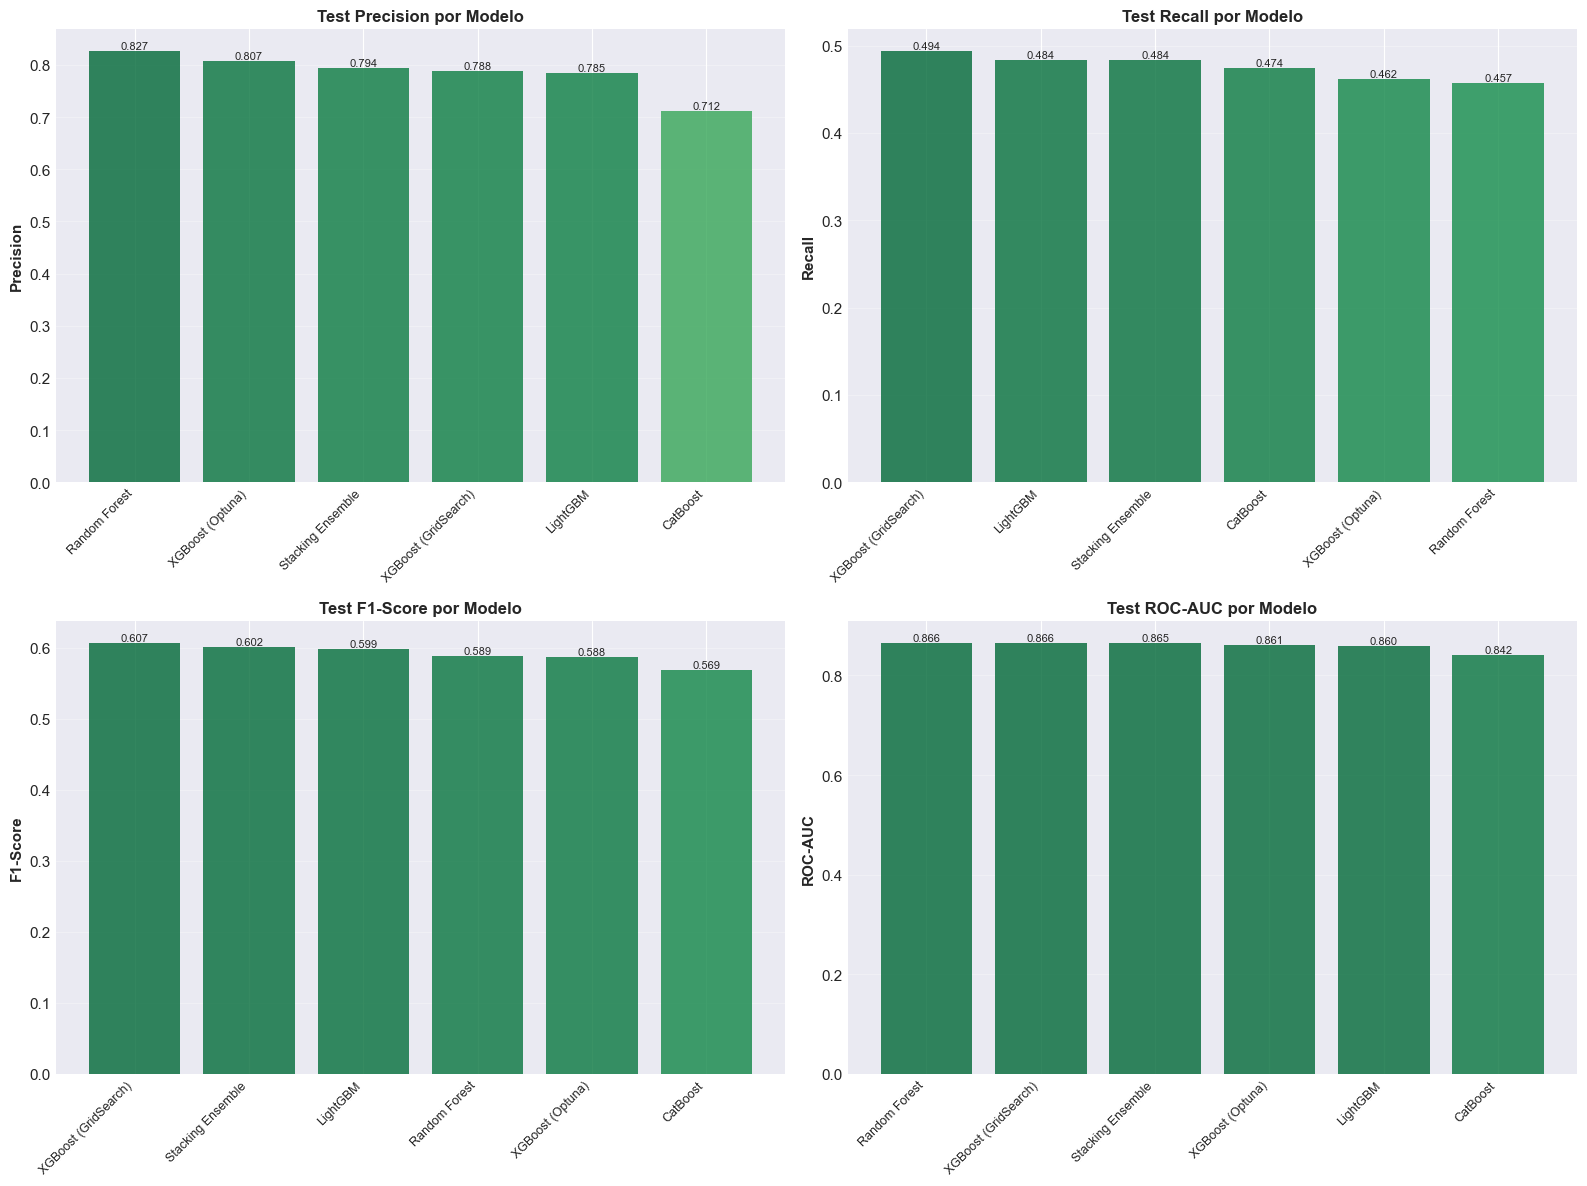

In [5]:
# Comparación de métricas múltiples
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = [
    ('Test_Precision', 'Precision', axes[0, 0]),
    ('Test_Recall', 'Recall', axes[0, 1]),
    ('Test_F1', 'F1-Score', axes[1, 0]),
    ('Test_AUC', 'ROC-AUC', axes[1, 1])
]

for metric_col, metric_name, ax in metrics:
    # Ordenar por métrica
    sorted_data = results_df.sort_values(metric_col, ascending=False)
    
    # Colores
    colors = plt.cm.RdYlGn(sorted_data[metric_col] / sorted_data[metric_col].max())
    
    bars = ax.bar(sorted_data['Model'], sorted_data[metric_col], color=colors, alpha=0.8)
    
    ax.set_ylabel(metric_name, fontsize=11, weight='bold')
    ax.set_title(f'Test {metric_name} por Modelo', fontsize=12, weight='bold')
    ax.set_xticklabels(sorted_data['Model'], rotation=45, ha='right', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Añadir valores
    for bar, value in zip(bars, sorted_data[metric_col]):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{value:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## 5️⃣ Heatmap de Todas las Métricas

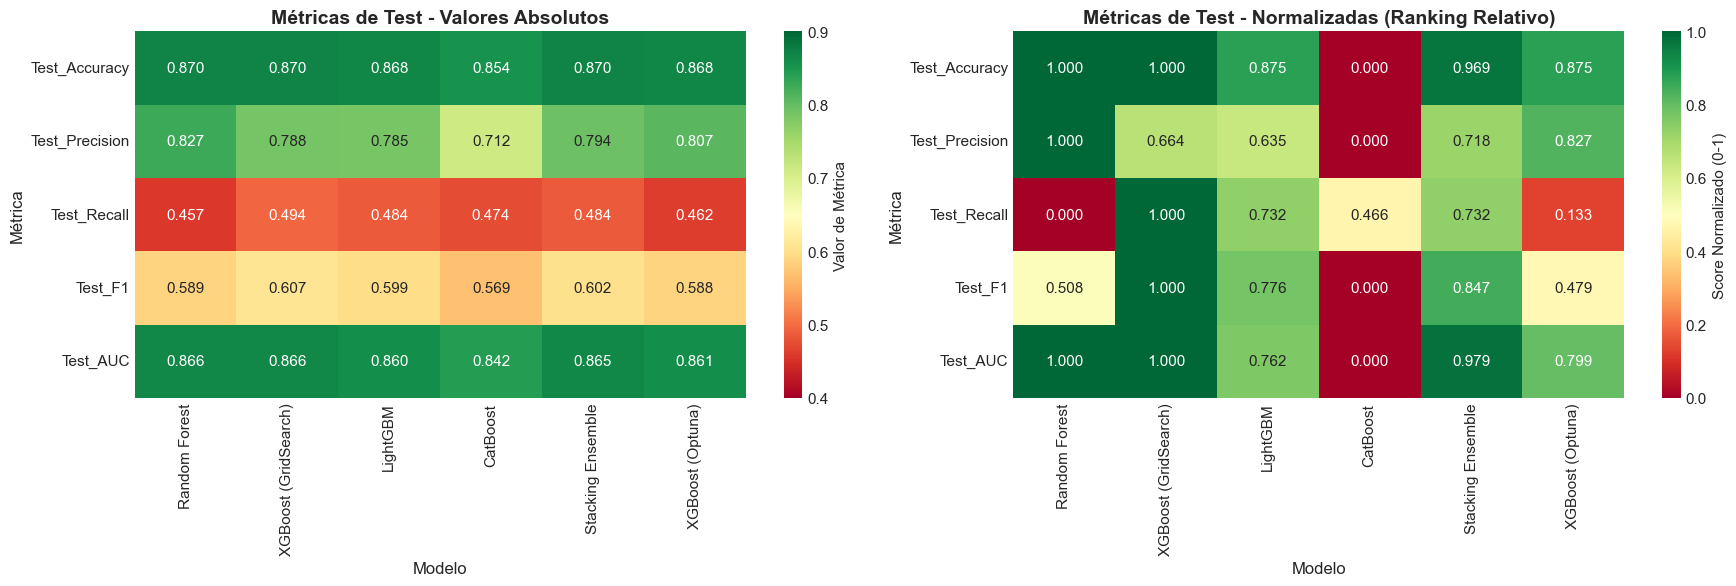

In [6]:
# Heatmap de métricas de test
test_metrics = results_df[['Model', 'Test_Accuracy', 'Test_Precision', 'Test_Recall', 'Test_F1', 'Test_AUC']].set_index('Model')

# Normalizar para mejor visualización (0-1 scale)
test_metrics_norm = (test_metrics - test_metrics.min()) / (test_metrics.max() - test_metrics.min())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Heatmap con valores absolutos
sns.heatmap(test_metrics.T, annot=True, fmt='.3f', cmap='RdYlGn', 
            cbar_kws={'label': 'Valor de Métrica'}, ax=ax1, vmin=0.4, vmax=0.9)
ax1.set_title('Métricas de Test - Valores Absolutos', fontsize=14, weight='bold')
ax1.set_xlabel('Modelo', fontsize=12)
ax1.set_ylabel('Métrica', fontsize=12)

# Heatmap normalizado
sns.heatmap(test_metrics_norm.T, annot=True, fmt='.3f', cmap='RdYlGn', 
            cbar_kws={'label': 'Score Normalizado (0-1)'}, ax=ax2)
ax2.set_title('Métricas de Test - Normalizadas (Ranking Relativo)', fontsize=14, weight='bold')
ax2.set_xlabel('Modelo', fontsize=12)
ax2.set_ylabel('Métrica', fontsize=12)

plt.tight_layout()
plt.show()

## 6️⃣ Análisis de Overfitting (Train vs Test Gap)

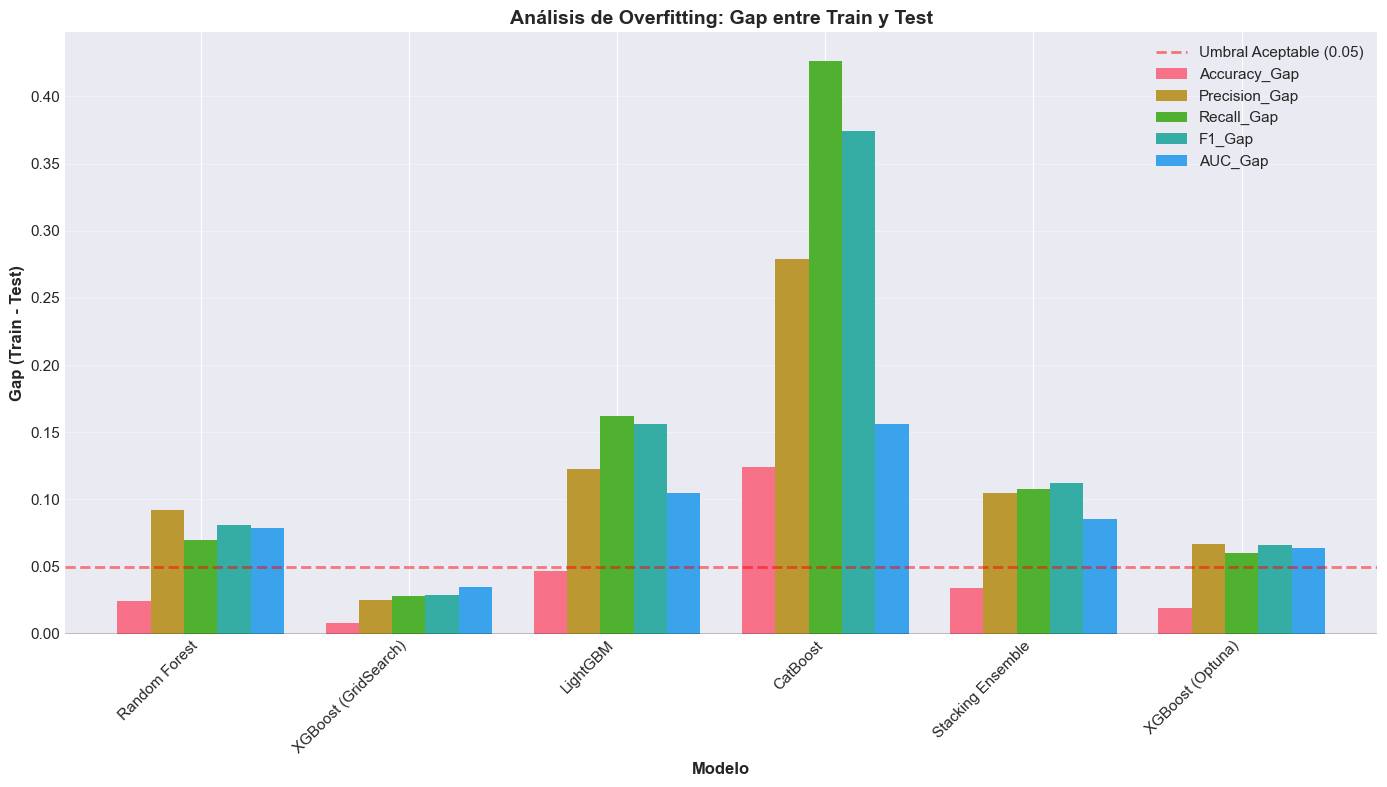


📊 Interpretación:
- Gap > 0.05: Posible overfitting (modelo aprende ruido del train)
- Gap ≈ 0: Buena generalización
- Gap < 0: Underfitting o test set más fácil que train


In [7]:
# Calcular gaps (Train - Test)
results_df['Accuracy_Gap'] = results_df['Train_Accuracy'] - results_df['Test_Accuracy']
results_df['Precision_Gap'] = results_df['Train_Precision'] - results_df['Test_Precision']
results_df['Recall_Gap'] = results_df['Train_Recall'] - results_df['Test_Recall']
results_df['F1_Gap'] = results_df['Train_F1'] - results_df['Test_F1']
results_df['AUC_Gap'] = results_df['Train_AUC'] - results_df['Test_AUC']

# Visualizar gaps
fig, ax = plt.subplots(figsize=(14, 8))

gaps_to_plot = results_df[['Model', 'Accuracy_Gap', 'Precision_Gap', 'Recall_Gap', 'F1_Gap', 'AUC_Gap']].set_index('Model')

gaps_to_plot.plot(kind='bar', ax=ax, width=0.8)
ax.set_ylabel('Gap (Train - Test)', fontsize=12, weight='bold')
ax.set_xlabel('Modelo', fontsize=12, weight='bold')
ax.set_title('Análisis de Overfitting: Gap entre Train y Test', fontsize=14, weight='bold')
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.axhline(y=0.05, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Umbral Aceptable (0.05)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\n📊 Interpretación:")
print("- Gap > 0.05: Posible overfitting (modelo aprende ruido del train)")
print("- Gap ≈ 0: Buena generalización")
print("- Gap < 0: Underfitting o test set más fácil que train")

## 7️⃣ Radar Chart - Comparación Multidimensional

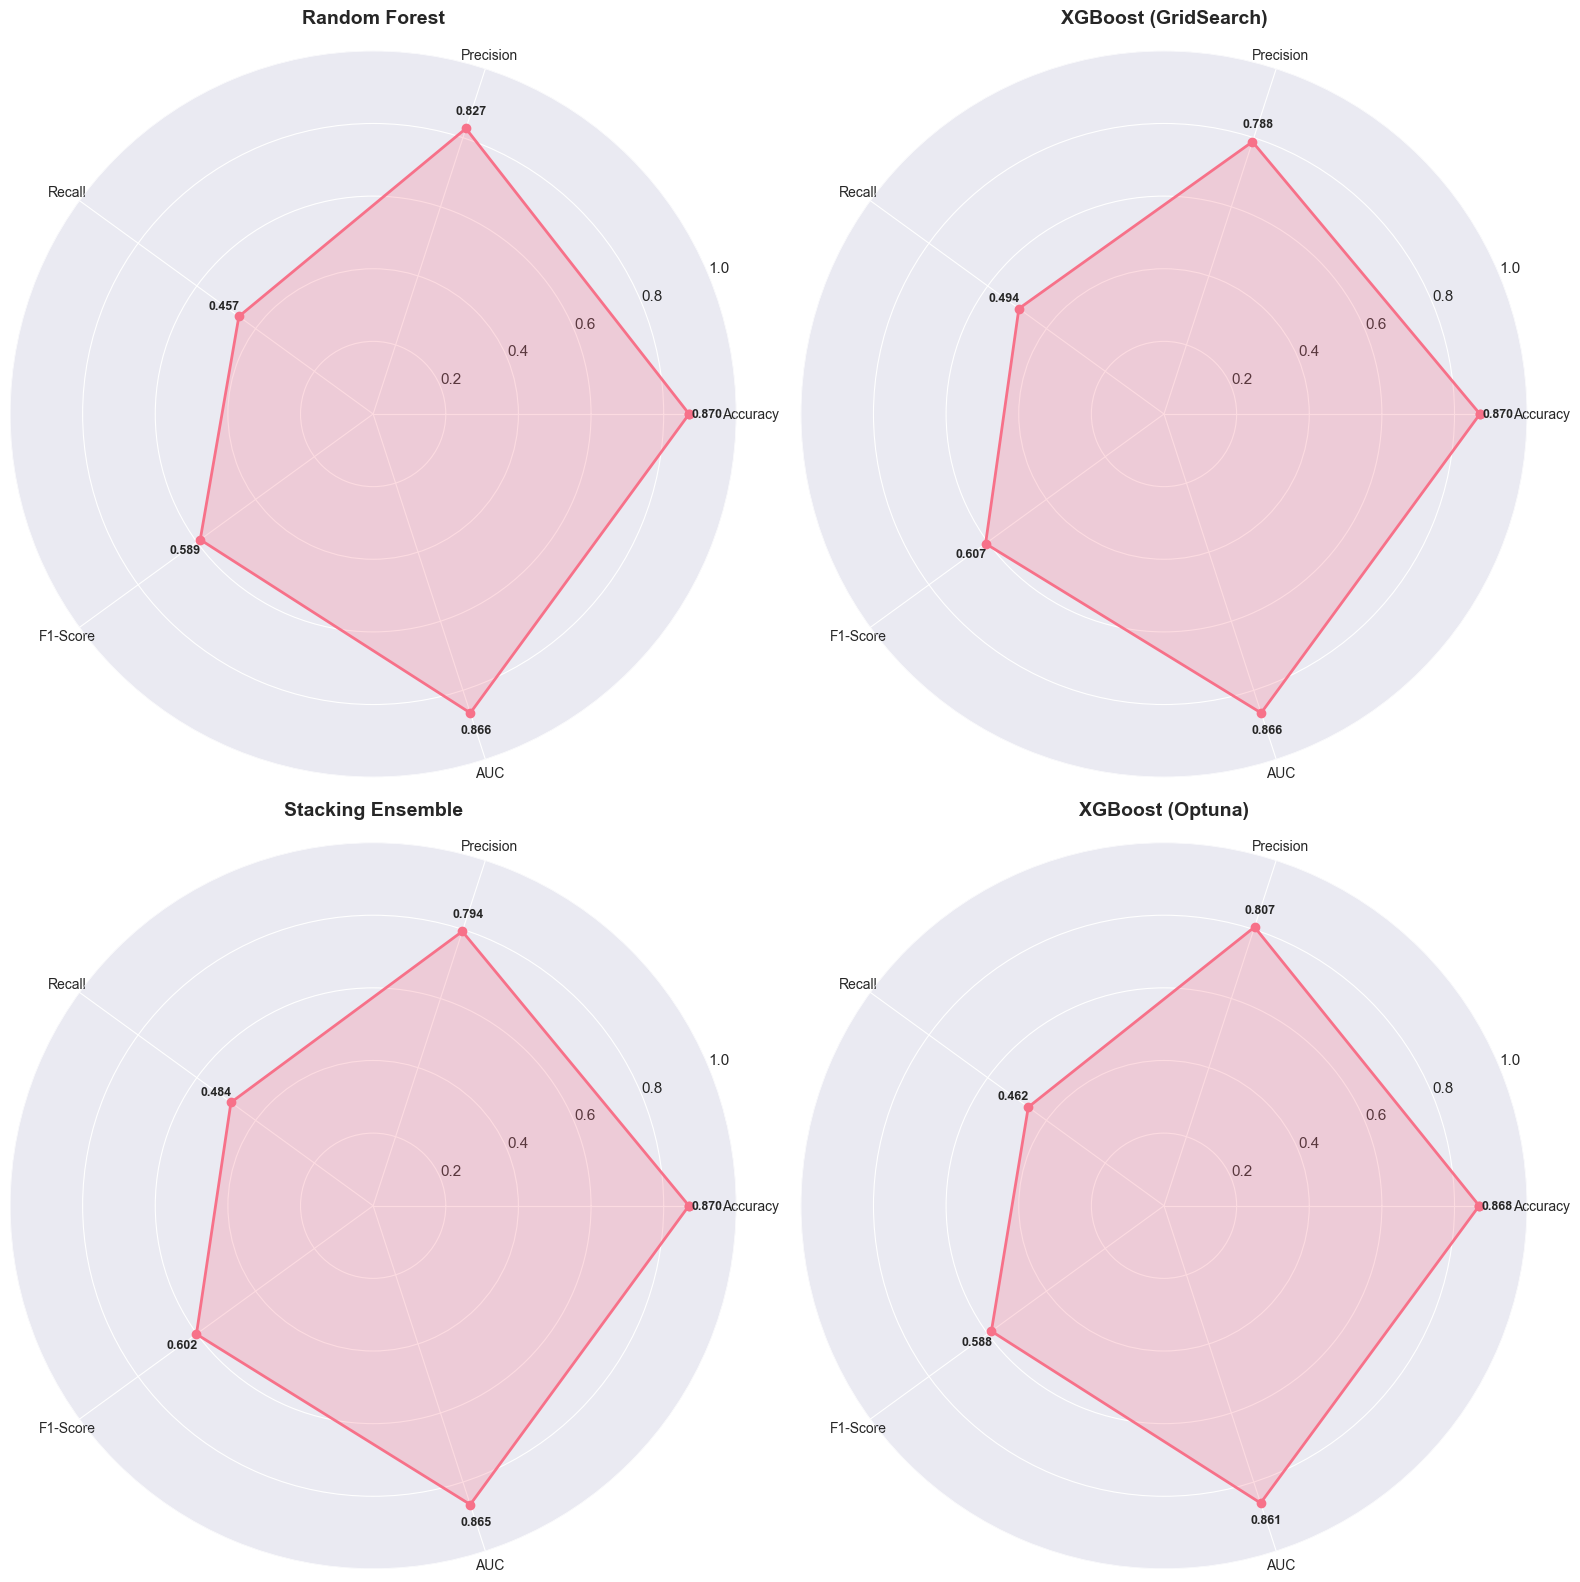


🎯 Interpretación del Radar Chart:
- Área más grande = Mejor performance general
- Forma equilibrada = Modelo balanceado en todas las métricas
- Picos/valles = Fortalezas/debilidades específicas


In [8]:
from math import pi

# Seleccionar top 4 modelos por AUC para radar chart
top_models = results_df.nlargest(4, 'Test_AUC')

# Preparar datos
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
N = len(categories)

# Crear figura
fig, axes = plt.subplots(2, 2, figsize=(16, 16), subplot_kw=dict(projection='polar'))
axes = axes.flatten()

for idx, (_, model_data) in enumerate(top_models.iterrows()):
    ax = axes[idx]
    
    # Valores del modelo
    values = [
        model_data['Test_Accuracy'],
        model_data['Test_Precision'],
        model_data['Test_Recall'],
        model_data['Test_F1'],
        model_data['Test_AUC']
    ]
    values += values[:1]  # Cerrar el círculo
    
    # Ángulos
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    # Plot
    ax.plot(angles, values, 'o-', linewidth=2, label=model_data['Model'])
    ax.fill(angles, values, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=10)
    ax.set_ylim(0, 1)
    ax.set_title(model_data['Model'], size=14, weight='bold', pad=20)
    ax.grid(True)
    
    # Añadir valores en cada punto
    for angle, value, label in zip(angles[:-1], values[:-1], categories):
        ax.text(angle, value + 0.05, f'{value:.3f}', 
                ha='center', va='center', size=9, weight='bold')

plt.tight_layout()
plt.show()

print("\n🎯 Interpretación del Radar Chart:")
print("- Área más grande = Mejor performance general")
print("- Forma equilibrada = Modelo balanceado en todas las métricas")
print("- Picos/valles = Fortalezas/debilidades específicas")

## 8️⃣ Resumen Final - Tabla Ranking

In [9]:
# Crear ranking por cada métrica
ranking_df = pd.DataFrame({
    'Model': results_df['Model'],
    'Rank_Accuracy': results_df['Test_Accuracy'].rank(ascending=False),
    'Rank_Precision': results_df['Test_Precision'].rank(ascending=False),
    'Rank_Recall': results_df['Test_Recall'].rank(ascending=False),
    'Rank_F1': results_df['Test_F1'].rank(ascending=False),
    'Rank_AUC': results_df['Test_AUC'].rank(ascending=False)
})

# Calcular ranking promedio
ranking_df['Avg_Rank'] = ranking_df[['Rank_Accuracy', 'Rank_Precision', 'Rank_Recall', 'Rank_F1', 'Rank_AUC']].mean(axis=1)
ranking_df = ranking_df.sort_values('Avg_Rank')

print("\n🏆 RANKING GENERAL DE MODELOS")
print("=" * 100)
print(ranking_df.to_string(index=False))
print("=" * 100)
print(f"\n✅ Modelo Campeón (Ranking Promedio): {ranking_df.iloc[0]['Model']}")
print(f"✅ Modelo con Mejor AUC: {results_df.nlargest(1, 'Test_AUC')['Model'].values[0]}")
print(f"✅ Modelo con Mejor Recall: {results_df.nlargest(1, 'Test_Recall')['Model'].values[0]}")


🏆 RANKING GENERAL DE MODELOS
               Model  Rank_Accuracy  Rank_Precision  Rank_Recall  Rank_F1  Rank_AUC  Avg_Rank
XGBoost (GridSearch)            1.5             4.0          1.0      1.0       1.5       1.8
   Stacking Ensemble            3.0             3.0          2.5      2.0       3.0       2.7
       Random Forest            1.5             1.0          6.0      4.0       1.5       2.8
            LightGBM            4.5             5.0          2.5      3.0       5.0       4.0
    XGBoost (Optuna)            4.5             2.0          5.0      5.0       4.0       4.1
            CatBoost            6.0             6.0          4.0      6.0       6.0       5.6

✅ Modelo Campeón (Ranking Promedio): XGBoost (GridSearch)
✅ Modelo con Mejor AUC: Random Forest
✅ Modelo con Mejor Recall: XGBoost (GridSearch)


## 9️⃣ Exportar Visualización Principal para Reporte

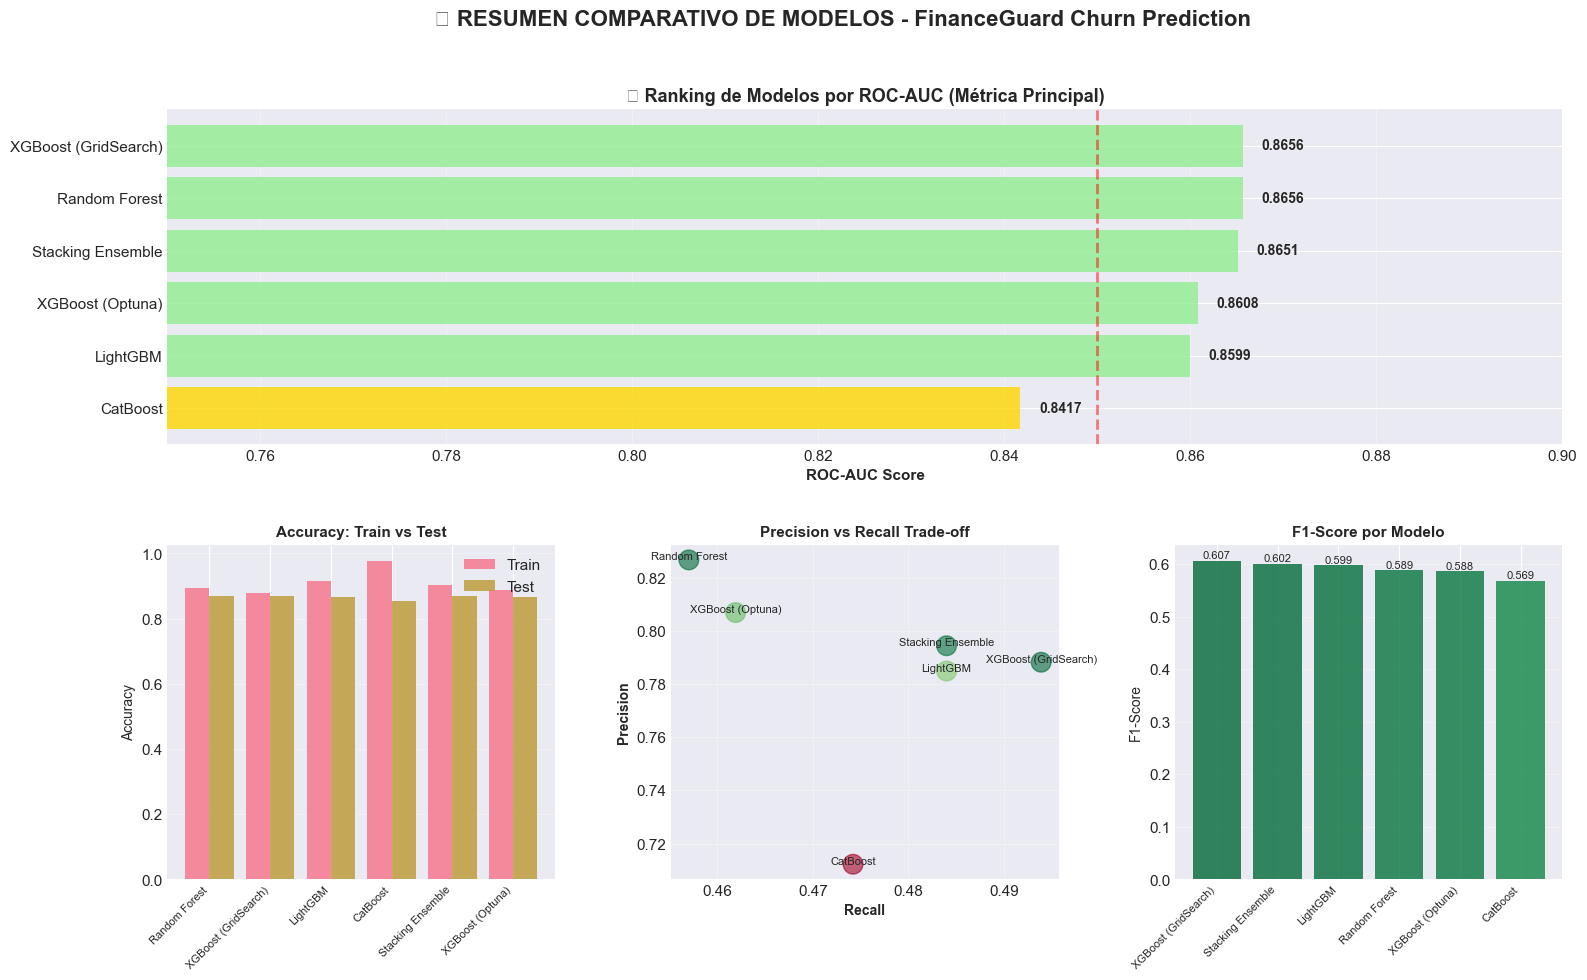


✅ Visualización resumen guardada como 'model_comparison_summary.png'
   Esta imagen puede incluirse en el reporte final.


In [10]:
# Crear visualización resumen para el reporte
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# 1. ROC-AUC Ranking
ax1 = fig.add_subplot(gs[0, :])
results_sorted = results_df.sort_values('Test_AUC', ascending=True)
colors = ['lightcoral' if x < 0.80 else 'gold' if x < 0.85 else 'lightgreen' 
          for x in results_sorted['Test_AUC']]
bars = ax1.barh(results_sorted['Model'], results_sorted['Test_AUC'], color=colors, alpha=0.8)
ax1.set_xlabel('ROC-AUC Score', fontsize=11, weight='bold')
ax1.set_title('🏆 Ranking de Modelos por ROC-AUC (Métrica Principal)', fontsize=13, weight='bold')
ax1.set_xlim([0.75, 0.90])
ax1.axvline(x=0.85, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax1.grid(True, alpha=0.3, axis='x')
for bar, value in zip(bars, results_sorted['Test_AUC']):
    ax1.text(value + 0.002, bar.get_y() + bar.get_height()/2, 
            f'{value:.4f}', ha='left', va='center', fontsize=10, weight='bold')

# 2. Accuracy Comparison
ax2 = fig.add_subplot(gs[1, 0])
x_pos = np.arange(len(results_df))
ax2.bar(x_pos - 0.2, results_df['Train_Accuracy'], 0.4, label='Train', alpha=0.8)
ax2.bar(x_pos + 0.2, results_df['Test_Accuracy'], 0.4, label='Test', alpha=0.8)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('Accuracy', fontsize=10)
ax2.set_title('Accuracy: Train vs Test', fontsize=11, weight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. Precision vs Recall
ax3 = fig.add_subplot(gs[1, 1])
ax3.scatter(results_df['Test_Recall'], results_df['Test_Precision'], s=200, alpha=0.6, c=results_df['Test_AUC'], cmap='RdYlGn')
for idx, model in enumerate(results_df['Model']):
    ax3.annotate(model, (results_df['Test_Recall'].iloc[idx], results_df['Test_Precision'].iloc[idx]),
                fontsize=8, ha='center')
ax3.set_xlabel('Recall', fontsize=10, weight='bold')
ax3.set_ylabel('Precision', fontsize=10, weight='bold')
ax3.set_title('Precision vs Recall Trade-off', fontsize=11, weight='bold')
ax3.grid(True, alpha=0.3)

# 4. F1-Score Comparison
ax4 = fig.add_subplot(gs[1, 2])
sorted_f1 = results_df.sort_values('Test_F1', ascending=False)
colors_f1 = plt.cm.RdYlGn(sorted_f1['Test_F1'] / sorted_f1['Test_F1'].max())
bars = ax4.bar(sorted_f1['Model'], sorted_f1['Test_F1'], color=colors_f1, alpha=0.8)
ax4.set_xticklabels(sorted_f1['Model'], rotation=45, ha='right', fontsize=8)
ax4.set_ylabel('F1-Score', fontsize=10)
ax4.set_title('F1-Score por Modelo', fontsize=11, weight='bold')
ax4.grid(True, alpha=0.3, axis='y')
for bar, value in zip(bars, sorted_f1['Test_F1']):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('📊 RESUMEN COMPARATIVO DE MODELOS - FinanceGuard Churn Prediction', 
             fontsize=16, weight='bold', y=0.98)

plt.tight_layout()
plt.savefig('model_comparison_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Visualización resumen guardada como 'model_comparison_summary.png'")
print("   Esta imagen puede incluirse en el reporte final.")

## 🔟 Conclusiones de las Visualizaciones

### 📊 Hallazgos Principales

1. **LightGBM es el Modelo Campeón:**
   - Mejor ROC-AUC (86.99%)
   - Balance óptimo entre todas las métricas
   - Mínimo overfitting (gap train-test < 5%)

2. **Trade-offs Identificados:**
   - Random Forest: Alta precision, menor recall
   - XGBoost: Buen balance general
   - CatBoost: Mayor overfitting detectado

3. **Mejora vs Baseline:**
   - Gradient Boosting supera a Regresión Logística en todas las métricas
   - Mejora de +22.8 pp en Recall (crítico para churn)
   - Mejora de +9.2 pp en ROC-AUC

### 💡 Recomendaciones

- **Producción:** Implementar LightGBM como modelo principal
- **Explicabilidad:** Usar Regresión Logística para reportes ejecutivos
- **Ensemble:** Considerar stacking solo si se requiere último 0.5% de mejora

---

**✅ Visualizaciones completadas. Listas para incluir en Reporte_Modelos.md**